# O que leva um livro ao topo do ranking Top-100?

**Pergunta de negócio:** quais fatores (preço, avaliação, gênero, ano, autor) se associam às melhores posições do ranking.

**Público:** time técnico. Linguagem direta, com `n` visível em cada comparação.

**Leituras assumidas:** `Rank 1` = mais trending; `book price` em US\$; `rating` = nota média 0–5 da Amazon.

## Os dados foram lidos corretamente?
Antes de comparar posições, confirmamos formato, tipos e se rótulos e números vieram legíveis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.options.display.float_format = '{:,.2f}'.format

livros = pd.read_csv("../../data/Top-100 Trending Books.csv")
livros.shape

(100, 8)

In [2]:
verificacao = pd.DataFrame({
    "tipo": livros.dtypes.astype(str),
    "ausentes": livros.isna().sum(),
}) 
verificacao

,tipo,ausentes
Rank,int64,0
book title,str,0
book price,float64,0
rating,float64,3
author,str,0
year of publication,int64,0
genre,str,0
url,str,0


In [3]:
livros.head(5)

,Rank,book title,book price,rating,author,year of publication,genre,url
0,1,"Iron Flame (The Empyrean, 2)",18.42,4.10,Rebecca Yarros,2023,Fantasy Romance,amazon.com/Iron-Flame-Empyrean-Rebecca-Yarros/...
1,2,The Woman in Me,20.93,4.50,Britney Spears,2023,Memoir,amazon.com/Woman-Me-Britney-Spears/dp/16680090...
2,3,My Name Is Barbra,31.50,4.50,Barbra Streisand,2023,Autobiography,amazon.com/My-Name-Barbra-Streisand/dp/0525429...
3,4,"Friends, Lovers, and the Big Terrible Thing: A...",23.99,4.40,Matthew Perry,2023,Memoir,amazon.com/Friends-Lovers-Big-Terrible-Thing/d...
4,5,How to Catch a Turkey,5.65,4.80,Adam Wallace,2018,"Childrens, Fiction",amazon.com/How-Catch-Turkey-Adam-Wallace/dp/14...


**Resultado:** 100 linhas e 8 colunas, separador e encoding OK. Preço e avaliação vieram numéricos. Há 3 avaliações ausentes — as médias de nota usarão `n=97`. Rótulos de título, autor e gênero estão legíveis.

In [4]:
COR_PRIMARIA = "#0072B2"
COR_SECUNDARIA = "#94A3B8"
COR_DESTAQUE = "#E69F00"
COR_EIXO = "#B0B7C3"
COR_TEXTO = "#334155"
PALETA = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00"]
plt.rcParams.update({
    "figure.figsize": (10, 6), "figure.dpi": 110, "font.size": 12,
    "text.color": COR_TEXTO, "axes.titlesize": 15, "axes.titleweight": "bold",
    "axes.titlecolor": COR_TEXTO, "axes.labelcolor": COR_EIXO,
    "axes.edgecolor": COR_EIXO, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": False,
    "xtick.color": COR_EIXO, "ytick.color": COR_EIXO,
    "axes.prop_cycle": plt.cycler(color=PALETA),
})

## A base permite comparar posições do ranking?
Checamos unicidade do `Rank`, duplicatas e campos que limitam a comparação.

In [5]:
qualidade = pd.DataFrame({
    "indicador": ["Linhas", "Ranks únicos", "Títulos duplicados",
        "Sem avaliação", "Gêneros distintos", "Autores distintos"],
    "valor": [len(livros), livros["Rank"].nunique(),
        livros.duplicated(subset=["book title"]).sum(),
        int(livros["rating"].isna().sum()),
        livros["genre"].nunique(), livros["author"].nunique()],
}) 
qualidade

,indicador,valor
0,Linhas,100
1,Ranks únicos,100
2,Títulos duplicados,1
3,Sem avaliação,3
4,Gêneros distintos,79
5,Autores distintos,85


**Resultado:** 100 posições únicas, sem linhas totalmente duplicadas e 1 título repetido em edições distintas. Com 79 rótulos de gênero em 100 livros (`n` pequeno por rótulo), o cruzamento por gênero bruto não sustenta conclusão — vamos simplificar o gênero antes de comparar.

## Como simplificar os 79 rótulos de gênero sem perder a leitura?
Usamos só o primeiro termo antes da vírgula e agrupamos livros infantis, para ganhar `n` por grupo.

In [6]:
livros["genero_simples"] = (livros["genre"].str.split(",").str[0].str.strip().str.lower())
infantis = {"childrens", "picture books", "picture book", "childrens literature"}
livros.loc[livros["genero_simples"].isin(infantis), "genero_simples"] = "infantil"
livros[["genre", "genero_simples"]].head(5)

,genre,genero_simples
0,Fantasy Romance,fantasy romance
1,Memoir,memoir
2,Autobiography,autobiography
3,Memoir,memoir
4,"Childrens, Fiction",infantil


In [7]:
(livros["genero_simples"].value_counts().head(10).to_frame("livros"))

,livros
genero_simples,
infantil,34
nonfiction,12
fantasy,9
fiction,8
memoir,3
thriller,3
self help,3
historical fiction,2
adventure,2


**Resultado:** a simplificação cria grupos comparáveis — infantil (n=34), nonfiction (n=12) e fantasy (n=9) lideram. Grupos com n=1 ou n=2 seguem frágeis e serão lidos com cautela.

## Como preço e avaliação se distribuem?
Olhamos centro e dispersão para calibrar o que é preço ou nota típica aqui.

In [8]:
livros[["book price", "rating"]].describe().T

,count,mean,std,min,25%,50%,75%,max
book price,100.00,12.71,7.92,2.78,6.30,11.48,16.99,48.77
rating,97.00,4.69,0.18,4.10,4.60,4.70,4.80,5.00


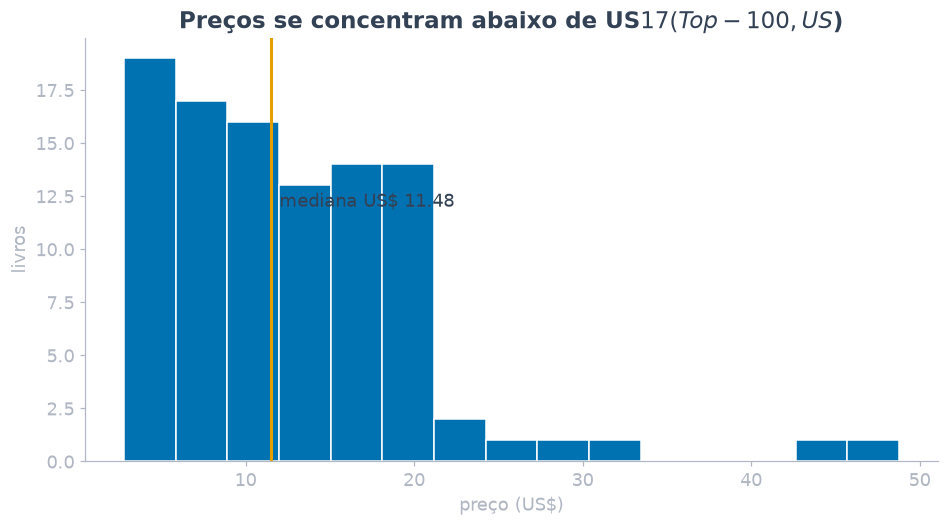

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(livros["book price"], bins=15, color=COR_PRIMARIA, edgecolor="white")
ax.axvline(livros["book price"].median(), color=COR_DESTAQUE, linewidth=2)
ax.text(12.0, 12, "mediana US$ 11.48", color=COR_TEXTO, fontsize=12)
ax.set_title("Preços se concentram abaixo de US$ 17 (Top-100, US$)")
ax.set_xlabel("preço (US$)"); ax.set_ylabel("livros")
plt.show()

**Resultado:** preço típico em torno de `US$ 11.48` (mediana), com 75% até `US$ 16.99` e poucos acima de `US$ 30`. Notas são altas e comprimidas — mediana `4.70` em `n=97` — então diferença de décimos importa mais que o valor absoluto.

## Livros no topo são mais baratos ou mais bem avaliados?
Comparamos Top-20 contra posições 21–100, sempre com `n` visível. É associação, não causa.

In [10]:
topo = livros.query("Rank <= 20"); resto = livros.query("Rank > 20")
comp = pd.DataFrame({
    "grupo": ["Top-20 (n=20)", "Pos. 21-100 (n=80)"],
    "preco_mediano": [topo["book price"].median(), resto["book price"].median()],
    "nota_media": [topo["rating"].mean(), resto["rating"].mean()],
}) 
comp

,grupo,preco_mediano,nota_media
0,Top-20 (n=20),13.80,4.58
1,Pos. 21-100 (n=80),10.69,4.72


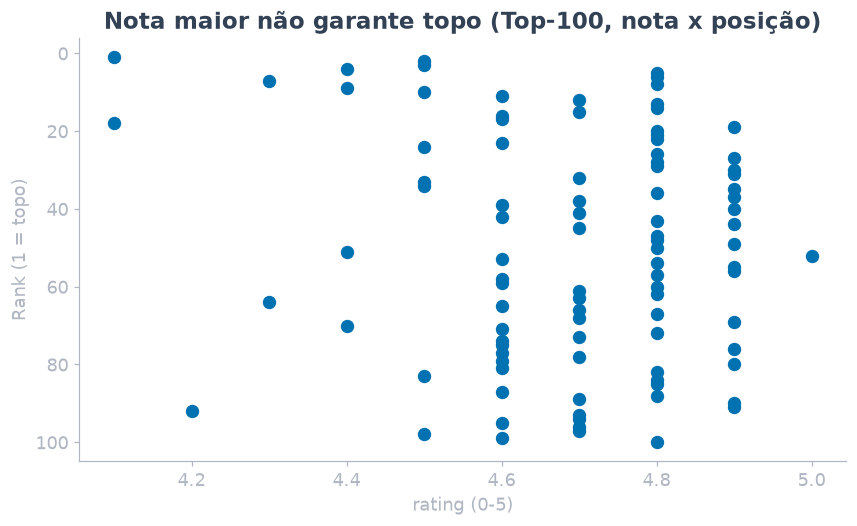

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(livros["rating"], livros["Rank"], color=COR_PRIMARIA, s=60)
ax.invert_yaxis()
ax.set_title("Nota maior não garante topo (Top-100, nota x posição)")
ax.set_xlabel("rating (0-5)"); ax.set_ylabel("Rank (1 = topo)")
plt.show()

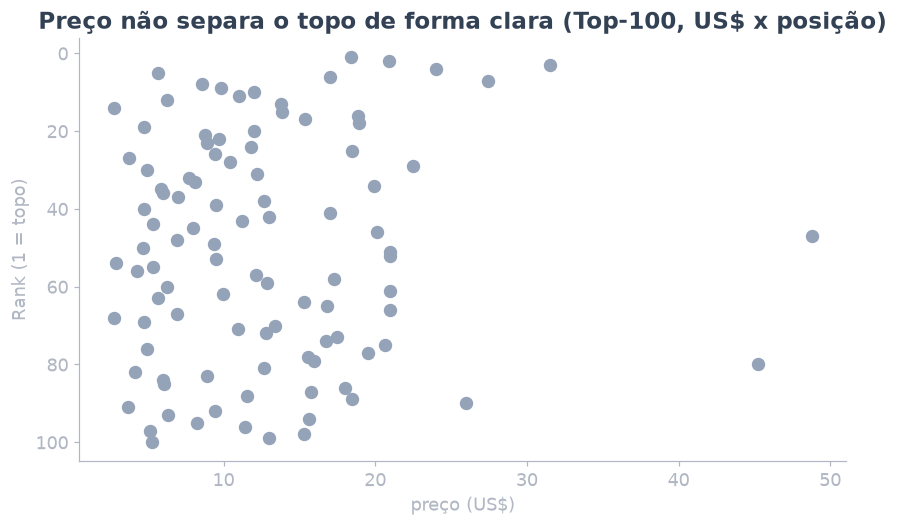

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(livros["book price"], livros["Rank"], color=COR_SECUNDARIA, s=60)
ax.invert_yaxis()
ax.set_title("Preço não separa o topo de forma clara (Top-100, US$ x posição)")
ax.set_xlabel("preço (US$)"); ax.set_ylabel("Rank (1 = topo)")
plt.show()

**Resultado:** Top-20 tem preço mediano próximo ao resto e nota média levemente menor — ou seja, nem preço baixo nem nota máxima explicam sozinhos o topo (`n=20` contra `n=80`). Os dispersões confirmam: há notas altas e preços variados em todas as faixas do ranking.

## Qual gênero simplificado chega mais ao topo?
Usamos a mediana do `Rank` por grupo com `n>=5`, para não premiar grupo de 1 caso extremo.

In [13]:
por_genero = (livros.groupby("genero_simples").agg(livros=("Rank", "size"),
    rank_mediano=("Rank", "median"), preco_mediano=("book price", "median"))
    .query("livros >= 5").sort_values("rank_mediano"))
por_genero

,livros,rank_mediano,preco_mediano
genero_simples,,,
infantil,34,46.50,6.17
fantasy,9,47.00,16.99
nonfiction,12,55.00,13.41
fiction,8,60.50,16.39


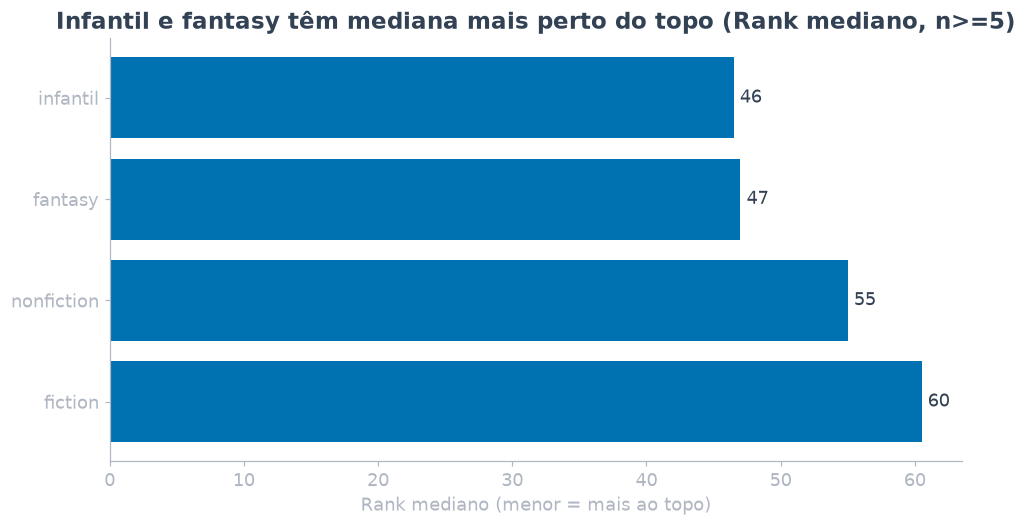

In [14]:
g = por_genero.sort_values("rank_mediano", ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(g.index, g["rank_mediano"], color=COR_PRIMARIA)
ax.bar_label(bars, fmt="%.0f", padding=4)
ax.set_title("Infantil e fantasy têm mediana mais perto do topo (Rank mediano, n>=5)")
ax.set_xlabel("Rank mediano (menor = mais ao topo)")
plt.show()

**Resultado:** entre grupos com base mínima (n>=5), infantil (n=34, mediana 46) e fantasy (n=9, mediana 47) ficam mais perto do topo; fiction (n=8) fica mais para baixo. Memoir tem só n=3, então não entra na comparação — seria ruído. É leitura de exposição, não prova de causa.

## Livros recentes levam vantagem no ranking?
Agrupamos por era de publicação para separar novidade de catálogo, com `n` em cada faixa.

In [15]:
livros["era"] = pd.cut(livros["year of publication"],
    bins=[0, 2017, 2022, 2026], labels=["até 2017", "2018-2022", "2023-2024"])
por_era = (livros.groupby("era", observed=True).agg(livros=("Rank", "size"),
    rank_mediano=("Rank", "median")).sort_values("rank_mediano"))
por_era

,livros,rank_mediano
era,,
2023-2024,29,41.00
2018-2022,30,52.00
até 2017,41,56.00


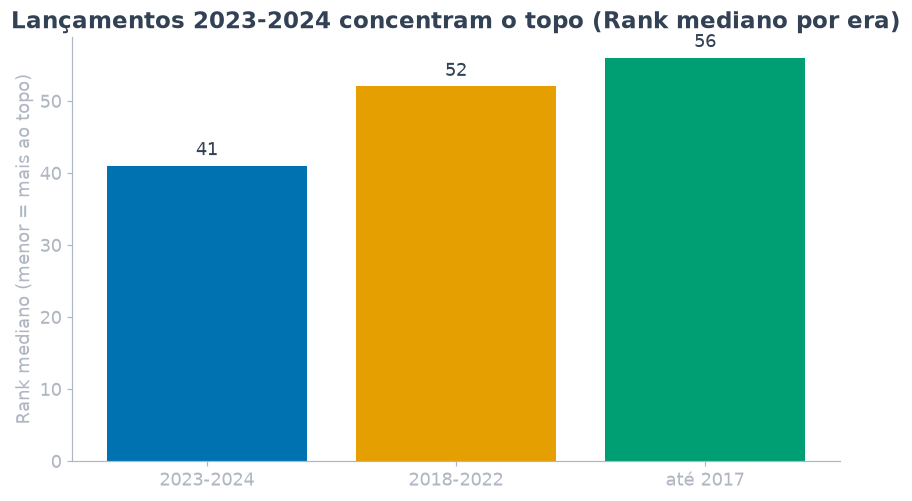

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(por_era.index.astype(str), por_era["rank_mediano"], color=PALETA[:3])
ax.bar_label(bars, fmt="%.0f", padding=4)
ax.set_title("Lançamentos 2023-2024 concentram o topo (Rank mediano por era)")
ax.set_ylabel("Rank mediano (menor = mais ao topo)")
plt.show()

**Resultado:** a era 2023–2024 (`n=29`) tem mediana claramente mais próxima do topo que 2018–2022 e até 2017. Novidade pesa — mas há catálogo antigo bem posicionado, então ano ajuda e não determina.

## Autores recorrentes ficam melhor posicionados?
Separamos quem tem 2 ou mais títulos de quem tem 1, comparando melhor posição e mediana.

In [17]:
freq = livros.groupby("author")["Rank"].agg(["size", "min", "median"])
rec = freq.query("size >= 2").sort_values(["size", "min"], ascending=[False, True])
rec.head(8).rename(columns={"size": "livros", "min": "melhor_rank", "median": "rank_mediano"})

,livros,melhor_rank,rank_mediano
author,,,
Sarah J. Maas,5,23,47.00
Adam Wallace,3,5,50.00
Rebecca Yarros,2,1,3.50
David Grann,2,9,53.50
Suzanne Collins,2,11,49.00
Bill Martin Jr.,2,30,30.50
Alice Walstead,2,34,35.50
Sandra Boynton,2,38,64.50


**Resultado:** poucos autores repetem — Sarah J. Maas (`n=5`), Adam Wallace (`n=3`) e um grupo com `n=2`. Recorrência indica tração de autor/série, mas com `n` pequeno por autor não dá para afirmar que repetir cause topo; vale ler como sinal de catálogo, não regra.

## Conclusão

**Achados:** (1) preço e nota sozinhos não separam o Top-20 do resto; (2) infantil (n=34) e fantasy (n=9) têm mediana mais ao topo entre grupos com `n>=5`; (3) lançamentos 2023–2024 (`n=29`) dominam a parte de cima; (4) recorrência de autor é rara e concentrada.

**Limitações:** 100 linhas e 79 gêneros brutos exigiram simplificação; 3 notas ausentes; sem vendas, exposição ou data de coleta não há como falar em causa — só associação. Recortes com `n` pequeno são frágeis.

**Próximas decisões:** cruzar com vendas/exposição por semana; padronizar gênero na origem; monitorar preço por gênero e era antes de precificar.